# Project 2: Supvervised Learning

## Total Points: 25

### Overview
In this project, you will **fine-tune an autoregressive language model (e.g., GPT-style) on a domain-specific**, labeled dataset using Parameter-Efficient Fine-Tuning (PEFT) techniques such as LoRA or adapters. The objective is to gain hands-on experience with preparing supervised data, applying PEFT to minimize training overhead, and evaluating the model’s performance on a task like text classification, summarization, or instruction following. You will compare the model's performance before and after fine-tuning using metrics such as accuracy, BLEU, or perplexity, depending on the task.

### 1. Identify the task and labeled datset
- Choose a supervised learning task such as text classification, summarization, question answering, or instruction following, preferably within a specific domain (e.g., legal, medical, finance, science, etc.).

- Select a labeled dataset appropriate for your task — one that includes both inputs and target outputs (e.g., prompts and responses, questions and answers, or documents and labels).

- Make sure the dataset is:
* Relevant to your chosen domain and task

* Small enough to fine-tune efficiently (especially with PEFT), but large enough to produce meaningful improvements

* You may need to experiment with dataset size or sampling to find a good balance between training time and performance.

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, AutoModelForSequenceClassification
from auto_gptq import AutoGPTQForCausalLM
from peft import prepare_model_for_kbit_training
from peft import LoraConfig, get_peft_model, PeftModel, PeftConfig
from datasets import load_dataset, Dataset, DatasetDict
import transformers
import torch
import auto_gptq
import optimum
import os
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import hf_xet
import ast
from datetime import datetime
from rouge_score import rouge_scorer
from sklearn.metrics import accuracy_score
import numpy as np
import bitsandbytes

CUDA extension not installed.
CUDA extension not installed.


In [2]:
# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cuda


In [3]:
model_name = "TheBloke/Mistral-7B-Instruct-v0.2-GPTQ"
model = AutoModelForCausalLM.from_pretrained(model_name,
                                             device_map="auto", 
                                             trust_remote_code=False,
                                             revision="main")

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
Some weights of the model checkpoint at TheBloke/Mistral-7B-Instruct-v0.2-GPTQ were not used when initializing MistralForCausalLM: ['model.layers.0.mlp.down_proj.bias', 'model.layers.0.mlp.gate_proj.bias', 'model.layers.0.mlp.up_proj.bias', 'model.layers.0.self_attn.k_proj.bias', 'model.layers.0.self_attn.o_proj.bias', 'model.layers.0.self_attn.q_proj.bias', 'model.layers.0.self_attn.v_proj.bias', 'model.layers.1.mlp.down_proj.bias', 'model.layers.1.mlp.gate_proj.bias', 'model.layers.1.mlp.up_proj.bias', 'model.layers.1.self_attn.k_proj.bias', 'model.layers.1.self_attn.o_proj.bias', 'model.layers.1.self_attn.q_proj.bias', 'model.layers.1.self_attn.v_proj.bias', 'model.layers.10.mlp.down_proj.bias', 'model.layers.10.mlp.gate_proj.bias', 'model.layers.10.mlp.up_proj.bias', 'model.layers.10.self_attn.k_proj.bias', 'model.layers.10.self_attn.o_proj.bias', 'model.layers.10.self_attn.q_pr

In [4]:
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

In [5]:
model.eval()

comment = "This book is so interesting to read! I love the fact that there's dragons and other mythical creatures in it."
prompt=f'''[INST] {comment} [/INST]\n\n'''

# tokenize input
inputs = tokenizer(prompt, return_tensors="pt")

# generate output
outputs = model.generate(input_ids=inputs["input_ids"].to("cuda"), max_new_tokens=140)

print(tokenizer.batch_decode(outputs)[0])

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<s> [INST] This book is so interesting to read! I love the fact that there's dragons and other mythical creatures in it. [/INST]

I'm glad to hear that you're enjoying the book with dragons and mythical creatures in it. These types of stories can transport us to magical worlds and offer a sense of wonder and excitement. The inclusion of dragons and other mythical creatures can add depth and complexity to the narrative, and can provide opportunities for exploring themes such as power, friendship, and the unknown. If you have any specific questions or topics related to the book or its creatures that you'd like to discuss, feel free to ask!</s>


In [6]:
instructions_string = f"""You are a book genre recommender.
You must classify the given review as ONLY one of the following categories:
Scifi
Fantasy
Romance
Health
Respond with ONLY one of these labels, and NOTHING ELSE.
"""

def build_prompt(x):
    # Define prompt template
    prompt_template = lambda comment: f"""[INST] {instructions_string} \nSMS Copy: {x} \nLabel: [/INST]"""

    

    # Generate prompt
    return (prompt_template(x))

In [7]:
# test out new prompt
comment = "An intriguing journey that keeps you turning the pages. The setting was rich and atmospheric, blending magic and mystery in a way that felt fresh and exciting. The characters' growth felt natural, and the unfolding events kept me guessing. A wonderful escape into another world."
prompt_comment = build_prompt(comment)
# tokenize input
inputs = tokenizer(prompt_comment, return_tensors="pt")

# generate output
outputs = model.generate(input_ids=inputs["input_ids"].to("cuda"), max_new_tokens=140)

print(tokenizer.batch_decode(outputs)[0])

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


<s> [INST] You are a book genre recommender.
You must classify the given review as ONLY one of the following categories:
Scifi
Fantasy
Romance
Health
Respond with ONLY one of these labels, and NOTHING ELSE.
 
SMS Copy: An intriguing journey that keeps you turning the pages. The setting was rich and atmospheric, blending magic and mystery in a way that felt fresh and exciting. The characters' growth felt natural, and the unfolding events kept me guessing. A wonderful escape into another world. 
Label: [/INST] Fantasy.</s>


### 2. Process Your Data
- Clean and preprocess the dataset to be suitable for an SL.
- Convert the dataset into a format compatible with your training pipeline. 
- Consider preprocessing your data to improve training quality.

In [8]:
# load cleaned data
df = pd.read_csv('cleanedBookData.csv')

In [9]:
df

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness
0,Fiction,10.95,0595344550,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,Veronica Haddon,iUniverse,2005,A3Q12RK71N74LB,Book Reader,I bought this book because I read some glowing...,2005,1.0,7/11
1,Fiction,10.95,0595344550,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,Veronica Haddon,iUniverse,2005,A1E9M6APK30ZAU,V. Powell,"I have to admit, I am not one to write reviews...",2005,4.0,1/2
2,Fiction,10.95,0595344550,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,Veronica Haddon,iUniverse,2005,AUR0VA5H0C66C,"LoveToRead ""Actually Read Books""","This is a self-published book, and if you want...",2005,1.0,1/2
3,Fiction,10.95,0595344550,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,Veronica Haddon,iUniverse,2005,A1YLDZ3VHR6QPZ,Clara,When I first read this the I was mezmerized at...,2005,5.0,2/4
4,Fiction,10.95,0595344550,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,Veronica Haddon,iUniverse,2005,ACO23CG8K8T77,Tonya,I read the review directly under mine and I ha...,2005,5.0,5/9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299744,Social Science,90.00,0786182431,Very Bad Deaths: Library Edition,This seven volume set reissues a collection of...,Various Authors,Routledge,2021,A1EC8SNPR56CLU,Denis Dube,"""Very Bad Death"" is a so so story, but the cha...",2010,4.0,0/0
299745,Social Science,90.00,0786182431,Very Bad Deaths: Library Edition,This seven volume set reissues a collection of...,Various Authors,Routledge,2021,A33VKWCAV9QQKC,"Paige E. Steadman ""RuneEnigma""",Very Bad Deaths was a very great book! Spider ...,2008,5.0,0/0
299746,Social Science,90.00,0786182431,Very Bad Deaths: Library Edition,This seven volume set reissues a collection of...,Various Authors,Routledge,2021,A2PK3NTC9RMEF4,S. Potter,Anything by Spider Robinson is worth reading. ...,2007,3.0,0/0
299747,Social Science,90.00,0786182431,Very Bad Deaths: Library Edition,This seven volume set reissues a collection of...,Various Authors,Routledge,2021,A2D0PY6HIGTYIT,"Adrian in Phoenix ""No Time for Fantasy""",Great novel! Easy & enjoyable to read straight...,2005,5.0,5/8


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299749 entries, 0 to 299748
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   categories          299749 non-null  object 
 1   Price               299749 non-null  float64
 2   Id                  299749 non-null  object 
 3   Title               299749 non-null  object 
 4   description         299749 non-null  object 
 5   authors             299749 non-null  object 
 6   publisher           299749 non-null  object 
 7   publishedDate       299749 non-null  int64  
 8   User_id             299749 non-null  object 
 9   profileName         299749 non-null  object 
 10  review/text         299749 non-null  object 
 11  review/time         299749 non-null  int64  
 12  review/score        299749 non-null  float64
 13  review/helpfulness  299749 non-null  object 
dtypes: float64(2), int64(2), object(10)
memory usage: 32.0+ MB


In [11]:
# # Print all unique categories
# unique_categories = df['categories'].unique().tolist()
# for category in unique_categories:
#     print(category)

# Get top 10 categories
top_categories = df['categories'].value_counts().head(10)
top_categories

categories
Fiction                      62908
Religion                     21154
Juvenile Fiction             15544
Biography & Autobiography    15236
History                      14558
Business & Economics         13949
Computers                    10977
Family & Relationships        8860
Cooking                       8355
Health & Fitness              7704
Name: count, dtype: int64

In [12]:
retained_categories = [
    'Fiction', 'Religion', 'Juvenile Fiction', 'History', 'Biography & Autobiography', 
    'Business & Economics', 'Computers', 'Juvenile Nonfiction', 
    'Social Science', 'Science'
]

# keep only retained_categories
df = df[df['categories'].isin(retained_categories)]

# grouped by categories
df = df.sort_values(by='categories')

In [13]:
# Show the updated df
df.head()

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness
94181,Biography & Autobiography,14.95,1892427168,From Basic To Baghdad,When homeschool graduate JB Hogan joined the A...,J. B. Hogan,Bright Ideas Press,2005,A2MF4QJJF2DYEA,K. D. Wilcox,I had the opportunity to read this book last w...,2005,5.0,5/5
273749,Biography & Autobiography,29.95,0700601104,The Presidency of George Washington (American ...,Assesses the importance of Washington's admini...,Forrest McDonald,Lawrence : University Press of Kansas,1974,A1S3C5OFU508P3,Charles Ashbacher,The general consensus is that the two greatest...,2001,5.0,10/11
273748,Biography & Autobiography,29.95,0700601104,The Presidency of George Washington (American ...,Assesses the importance of Washington's admini...,Forrest McDonald,Lawrence : University Press of Kansas,1974,A32ZKBXJJ45BRY,James Gallen,"""The Presidency of George Washington"" is exact...",2002,4.0,14/14
273738,Biography & Autobiography,19.98,1411616561,A Perfectly Good Dog,A well written collection of stories on living...,Grace Saalsaa,Lulu.com,2004,ABF58ITHUYU3,"Certified Master Dog Trainer & Author ""Everyt...",Get out the tissues!... this book is a real he...,2005,5.0,0/0
273737,Biography & Autobiography,19.98,1411616561,A Perfectly Good Dog,A well written collection of stories on living...,Grace Saalsaa,Lulu.com,2004,AUMVRXK0P29CF,Jayne Poyer,This book is a must read for any dog lover. Th...,2005,5.0,1/1


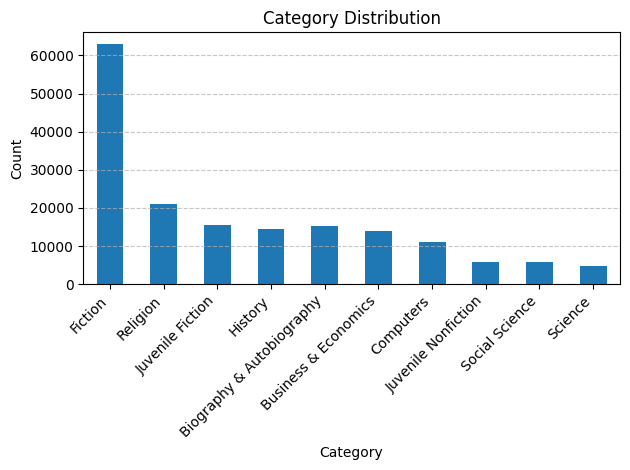

In [14]:
category_counts = df['categories'].value_counts().loc[retained_categories]

category_counts.plot(kind='bar', title='Category Distribution', ylabel='Count', xlabel='Category')

plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
# sampling down to 10k rows
sampled_df = df.sample(n=10000, random_state=42)
sampled_df.head()

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness
248692,Fiction,7.99,0515136379,Key of Knowledge,With the promise of a million dollars each dan...,Nora Roberts,Berkley,2015,ASFTBEXX03AVC,"K. Mulkey ""jmul1186""",You can never go wrong with a Nora Roberts rom...,2007,5.0,0/0
158759,Fiction,24.50,1593351380,Monkeewrench (Monkeewrench Series),People are dying for the new computer game by ...,P. J. Tracy,Penguin,2004,A3OGDI2YRV8INW,Kathy Moody,Had this book in my library for a long time an...,2013,5.0,0/0
248491,Fiction,10.17,0393319296,Invisible Monsters: A Novel,"When a freeway ""accident"" leaves a beautiful f...",Chuck Palahniuk,W. W. Norton & Company,1999,A3JMWIOTUBOJI7,Donkey Dick,"With each passing book, Palahniuk gets even st...",2002,1.0,4/22
39851,Fiction,7.99,0380820994,Vineyard Shadows: A Martha's Vineyard Mystery,It’s just another gorgeous June day on Martha’...,Philip R. Craig,Simon and Schuster,2001,A2MB5XC5QP3WBW,"Ricky N. ""Ricky C. Nelson""","I read ""Vineyard Shadows"" by Philip R. Craig b...",2005,3.0,8/8
82570,Fiction,117.25,1596009896,Dragonsdawn (Dragonriders of Pern Series),NEW YORK TIMES BESTSELLER • Go back in time an...,Anne McCaffrey,Del Rey,2002,AR4W703CBURLN,Joseph K.,This book will keep you guessing how one thing...,2005,4.0,1/1


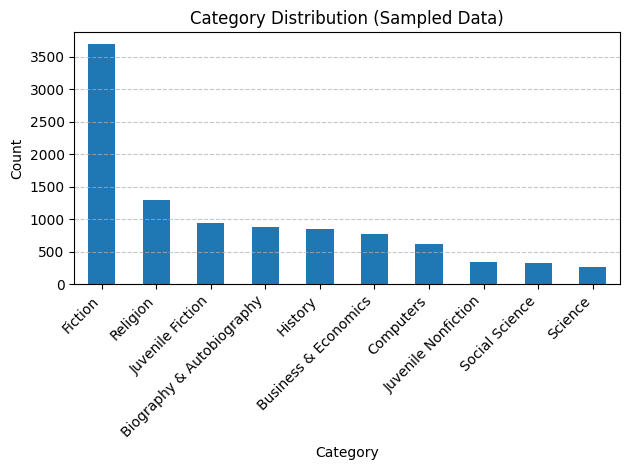

In [16]:
sampled_category_counts = sampled_df['categories'].value_counts().sort_values(ascending=False)

sampled_category_counts.plot(kind='bar', title='Category Distribution (Sampled Data)', ylabel='Count', xlabel='Category')
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
# Adjusting instructions
instructions_string = f"You are a book recommender. Respond to the user's request by recommending a book that fits their needs. Also include the reason for your recommendation, such as low price, matching genre, or specific themes found in the review or description."

def build_prompt(row):
    # Start prompt with instructions
    prompt = f"[INST] {instructions_string}\n"
    
    # Dynamically add columns if they exist and are non-empty
    if 'Title' in row and pd.notna(row['Title']):
        prompt += f"Book Title: {row['Title']}\n"
    if 'description' in row and pd.notna(row['description']):
        prompt += f"Description: {row['description']}\n"
    if 'review/text' in row and pd.notna(row['review/text']):
        prompt += f"User Review: {row['review/text']}\n"
    if 'Price' in row and pd.notna(row['Price']):
        prompt += f"Price: ${row['Price']}\n"
    if 'categories' in row and pd.notna(row['categories']):
        prompt += f"Category: {row['categories']}\n"
    if 'User_id' in row and pd.notna(row['User_id']):
        prompt += f"User ID: {row['User_id']}\n"
    
    # Close the instruction prompt
    prompt += "Recommendation: [/INST]"
    
    return prompt

In [18]:
sampled_df['prompt_copy'] = sampled_df.apply(build_prompt, axis=1)
sampled_df

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness,prompt_copy
248692,Fiction,7.99,0515136379,Key of Knowledge,With the promise of a million dollars each dan...,Nora Roberts,Berkley,2015,ASFTBEXX03AVC,"K. Mulkey ""jmul1186""",You can never go wrong with a Nora Roberts rom...,2007,5.0,0/0,[INST] You are a book recommender. Respond to ...
158759,Fiction,24.50,1593351380,Monkeewrench (Monkeewrench Series),People are dying for the new computer game by ...,P. J. Tracy,Penguin,2004,A3OGDI2YRV8INW,Kathy Moody,Had this book in my library for a long time an...,2013,5.0,0/0,[INST] You are a book recommender. Respond to ...
248491,Fiction,10.17,0393319296,Invisible Monsters: A Novel,"When a freeway ""accident"" leaves a beautiful f...",Chuck Palahniuk,W. W. Norton & Company,1999,A3JMWIOTUBOJI7,Donkey Dick,"With each passing book, Palahniuk gets even st...",2002,1.0,4/22,[INST] You are a book recommender. Respond to ...
39851,Fiction,7.99,0380820994,Vineyard Shadows: A Martha's Vineyard Mystery,It’s just another gorgeous June day on Martha’...,Philip R. Craig,Simon and Schuster,2001,A2MB5XC5QP3WBW,"Ricky N. ""Ricky C. Nelson""","I read ""Vineyard Shadows"" by Philip R. Craig b...",2005,3.0,8/8,[INST] You are a book recommender. Respond to ...
82570,Fiction,117.25,1596009896,Dragonsdawn (Dragonriders of Pern Series),NEW YORK TIMES BESTSELLER • Go back in time an...,Anne McCaffrey,Del Rey,2002,AR4W703CBURLN,Joseph K.,This book will keep you guessing how one thing...,2005,4.0,1/1,[INST] You are a book recommender. Respond to ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251512,Science,30.00,0674950852,What Makes Nature Tick?,"For many of us, the physical sciences are as o...",Roger G. Newton,Harvard University Press,1993,AENXJM2CKEN5L,"Joe Zika ""Khemprof""",What Makes Nature Tick? written by Roger G. Ne...,2002,5.0,4/4,[INST] You are a book recommender. Respond to ...
262733,Juvenile Fiction,10.87,0689818637,Bed Bugs: A Pop-up Bedtime Book,Get ready for bed with the Jitterbugs in this ...,David A. Carter,Little Simon,1998,A1NHIMW2RBWX0Q,Southerngirl,My daughter loved David Carter books from 1 - ...,2009,5.0,1/1,[INST] You are a book recommender. Respond to ...
234316,Juvenile Fiction,7.99,0439279895,Pure Sunshine (Push),A spellbinding trip of a novel about three fri...,Brian James,Scholastic Inc.,2009,A22MRI0XWBNP46,"Reading Student ""Santa Fe Community College""",Pure Sunshine by Brian James is a story that b...,2009,3.0,0/0,[INST] You are a book recommender. Respond to ...
3502,Fiction,10.19,0764229893,Gods and Kings (Chronicles of the Kings #1),"Gods and Kings is the story of King Hezekiah, ...",Lynn Austin,Bethany House Publishers,2005,A1G7GG77D42I2I,Beverly Storey,This was a great book to read. I had a hard ti...,2013,1.0,0/8,[INST] You are a book recommender. Respond to ...


### 3. Baseline Measurement
* Before fine-tuning, evaluate the performance of a pretrained autoregressive language model on your supervised task.

* Use your labeled dataset in its original input-output format (e.g., prompt → response, input → label).

* Measure how well the model performs without fine-tuning, using metrics appropriate for your task:

* Accuracy, F1-score for classification

* BLEU, ROUGE, or exact match for generation or QA


* This will serve as your baseline for comparing performance after PEFT fine-tuning.

In [19]:
train_df, val_df = train_test_split(
    sampled_df,
    test_size=0.2,
    stratify=sampled_df['categories'], # Keep the categories balanced
    random_state=42
)

# Check the split
print("Training set size:", len(train_df))
print("Validation set size:", len(val_df))

Training set size: 8000
Validation set size: 2000


In [20]:
val_df.head()

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness,prompt_copy
280001,Juvenile Fiction,15.99,0312338376,Introducing Vivien Leigh Reid: Daughter of the...,A fifteen-year-old is less than thrilled to be...,"Yvonne Collins, Sandy Rideout",Macmillan,2005,A1SX0PQUE76M1S,bronwyn,"This is an amazing book, but not just because ...",2005,5.0,1/1,[INST] You are a book recommender. Respond to ...
59987,Religion,12.36,0300076614,Mary Through the Centuries: Her Place in the H...,Explores how Mary has been represented in theo...,Jaroslav Pelikan,Yale University Press,1996,A13UP6AMGREFA7,"Betty Martin ""grad student""",Book Review:Mary Through the Centuries: Her Pl...,2010,5.0,3/3,[INST] You are a book recommender. Respond to ...
64332,Fiction,7.99,0451214943,"Fire Me Up (Aisling Grey, Guardian, Book 2)","Aisling Grey, dealing with her new vocation as...",Katie MacAlister,Penguin,2005,A3QSB6EYH57P4S,S. Stephens,A good continutation of the saga - Aisling is ...,2005,5.0,0/0,[INST] You are a book recommender. Respond to ...
35684,Biography & Autobiography,13.43,0966638980,Black Edelweiss: A Memoir of Combat and Consci...,When a 20-year old Waffen-SS veteran of two ye...,Johann Voss,Aegis Consulting Group,2002,A3CF9Z2OQ954UP,jimplunkett,"I am veteran of the 3ID, serving in the 90's. ...",2011,5.0,3/4,[INST] You are a book recommender. Respond to ...
174312,Juvenile Fiction,20.44,0881034185,The Lorax (Turtleback School & Library Binding...,"Easy-to-read, rhyming text introduces the Lora...",Tish Rabe,Random House Books for Young Readers,2012,A1KYJA5YM1479G,"K. ""Take a look it's in a book...Reading Rain...",Fantastic book for kids! So imaginative and cr...,2013,5.0,0/0,[INST] You are a book recommender. Respond to ...


In [21]:
# Function for batch inference
def batch_inference(prompts, batch_size=16):
    results = []
    
    # Iterate through the prompts in batches
    for i in tqdm(range(0, len(prompts), batch_size), desc="Running Mistral Inference"):
        batch = prompts[i:i+batch_size]
        
        # Tokenize the batch of prompts
        inputs = tokenizer.batch_encode_plus(batch, return_tensors="pt", padding=True, truncation=True).to("cuda")
        
        # Perform inference (using model.generate)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_new_tokens=100,  # Increase the number of new tokens for longer recommendations
                do_sample=True,  # Enables sampling for more creative results (autoregressive generation)
                top_k=50,
                top_p=0.95,
                temperature=0.7,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id
            )
        
        # Decode the outputs to get readable text
        decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        
        # Remove the original prompt from the output (cleaning)
        cleaned_outputs = [output.replace(prompt, "").strip() for output, prompt in zip(decoded_outputs, batch)]
        
        # Collect the results
        results.extend(cleaned_outputs)
    
    return results

In [22]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

baseline = val_df.copy()
baseline["mistral"] = batch_inference(baseline["prompt_copy"].tolist())

# Print the unique generated recommendations
print(baseline.mistral.unique())
baseline.head()

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Running Mistral Inference: 100%|██████████| 125/125 [3:08:16<00:00, 90.37s/it]   

['Based on your review and the description of "Introducing Vivien Leigh Reid: Daughter of a Diva," I would highly recommend this book to you, A1SX0PQUE76M1S. This book seems to align perfectly with your interests as it also includes themes of romance, relationship building, and a mother-daughter dynamic, all set against the backdrop of Ireland and the film industry. The review also mentions the presence of humor and character'
 'Based on your interest in the history of Mary\'s cultural and doctrinal influences on the Western world, I would highly recommend the book "Mary Through the Centuries: Her Place in the History of Culture" by Jaroslav Pelikan.\n\nThe reason for my recommendation is that this book matches the genre you have shown an interest in, and it specifically addresses the topic of Mary\'s impact on theology, art, music, and literature throughout history. The review also praises'
 'Based on your review and the fact that you enjoyed the first book in the series and are looki

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness,prompt_copy,mistral
280001,Juvenile Fiction,15.99,0312338376,Introducing Vivien Leigh Reid: Daughter of the...,A fifteen-year-old is less than thrilled to be...,"Yvonne Collins, Sandy Rideout",Macmillan,2005,A1SX0PQUE76M1S,bronwyn,"This is an amazing book, but not just because ...",2005,5.0,1/1,[INST] You are a book recommender. Respond to ...,"Based on your review and the description of ""I..."
59987,Religion,12.36,0300076614,Mary Through the Centuries: Her Place in the H...,Explores how Mary has been represented in theo...,Jaroslav Pelikan,Yale University Press,1996,A13UP6AMGREFA7,"Betty Martin ""grad student""",Book Review:Mary Through the Centuries: Her Pl...,2010,5.0,3/3,[INST] You are a book recommender. Respond to ...,Based on your interest in the history of Mary'...
64332,Fiction,7.99,0451214943,"Fire Me Up (Aisling Grey, Guardian, Book 2)","Aisling Grey, dealing with her new vocation as...",Katie MacAlister,Penguin,2005,A3QSB6EYH57P4S,S. Stephens,A good continutation of the saga - Aisling is ...,2005,5.0,0/0,[INST] You are a book recommender. Respond to ...,Based on your review and the fact that you enj...
35684,Biography & Autobiography,13.43,0966638980,Black Edelweiss: A Memoir of Combat and Consci...,When a 20-year old Waffen-SS veteran of two ye...,Johann Voss,Aegis Consulting Group,2002,A3CF9Z2OQ954UP,jimplunkett,"I am veteran of the 3ID, serving in the 90's. ...",2011,5.0,3/4,[INST] You are a book recommender. Respond to ...,Based on your user review and your expressed i...
174312,Juvenile Fiction,20.44,0881034185,The Lorax (Turtleback School & Library Binding...,"Easy-to-read, rhyming text introduces the Lora...",Tish Rabe,Random House Books for Young Readers,2012,A1KYJA5YM1479G,"K. ""Take a look it's in a book...Reading Rain...",Fantastic book for kids! So imaginative and cr...,2013,5.0,0/0,[INST] You are a book recommender. Respond to ...,Based on your positive review of Dr. Seuss's i...


In [23]:
def calculate_bleu(reference, candidate):
    reference = reference.split()  # Tokenize the reference
    candidate = candidate.split()  # Tokenize the candidate
    score = sentence_bleu([reference], candidate)
    return score

bleu_scores = []

In [24]:
references = baseline['review/text'].astype(str).tolist()  # Use review/text as reference
candidates = baseline['mistral'].astype(str).tolist()  # Model-generated recommendations

In [25]:
# Loop through the references and candidates to calculate BLEU
for ref, cand in zip(references, candidates):
    bleu_score = calculate_bleu(ref, cand)
    bleu_scores.append(bleu_score)

# Calculate average BLEU score
avg_bleu = np.mean(bleu_scores)

D:\programs\anaconda\envs\new\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
D:\programs\anaconda\envs\new\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
D:\programs\anaconda\envs\new\lib\site-packages\nltk\translate\bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunc

In [26]:
# Print the average BLEU score
print(f"BLEU Score: {avg_bleu:.4f}")

BLEU Score: 0.0110


In [27]:
baseline.to_pickle('baseline.pk')

### Training

In [28]:
model.train()
model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

In [29]:
config = LoraConfig(
    r=8,  # Rank of low-rank matrices
    lora_alpha=32,  # Scaling factor for LoRA
    target_modules=["q_proj"],  # Target the query projection (q_proj)
    lora_dropout=0.05,  # Dropout rate for LoRA layers
    bias="none",  # No biases added to LoRA layers
    task_type="CAUSAL_LM"  # Fine-tuning for causal language modeling
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 2,097,152 || all params: 264,507,392 || trainable%: 0.7929


In [30]:
#convert to hf dataset
train_dataset = Dataset.from_pandas(pd.DataFrame({
    "text": sampled_df["review/text"].tolist(),
    "label": sampled_df["review/score"].tolist()  # ['review/score'] as labels for training
}))

val_dataset = Dataset.from_pandas(pd.DataFrame({
    "text": val_df["review/text"].tolist(),
    "label": val_df["review/score"].tolist()  # validation
}))

# Combine into a DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "test": val_dataset
})

In [31]:
dataset['train'][0]

{'text': 'You can never go wrong with a Nora Roberts romance novel and this is just one more great one in the list.',
 'label': 5.0}

In [32]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [33]:
def preprocess_function(examples):
    prompts = [f"Review: {text}\nRating:" for text in examples["text"]]
    targets = examples["label"]

    full_texts = [p + " " + str(t) for p, t in zip(prompts, targets)]  # Convert target to string

    # Tokenize as a single sequence
    tokenized = tokenizer(
        full_texts,
        padding="max_length",
        truncation=True,
        max_length=150,
    )
    
    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized

In [34]:
tokenized_data = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [35]:
tokenized_data

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

In [36]:
tokenizer.pad_token = tokenizer.eos_token
data_collator = transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)

In [43]:
# training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="train_proj2",
    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    gradient_accumulation_steps=4,
    warmup_steps=2,
    fp16=True,
    optim="paged_adamw_8bit",
    logging_dir="./logs",
    logging_strategy="steps",
    logging_steps=150,
    save_total_limit=3
)

### 4. Fine-Tune a AR model using PEFT
* Fine-tune a pretrained autoregressive language model on your domain-specific, labeled dataset using Parameter-Efficient Fine-Tuning (PEFT) with LoRA (Low-Rank Adaptation).

* Use a PEFT framework such as the Hugging Face peft library to integrate LoRA into your training pipeline.

* LoRA modifies only a small subset of the model's parameters, allowing for efficient training even on limited hardware.

* Implement a training loop or use tools like Trainer or accelerate for easier setup.

* After training, save the LoRA adapter weights for reuse or evaluation — you can later merge them with the base model if needed.


In [44]:
# Preprocessing function to tokenize data
def preprocess_function(examples):
    prompts = [f"Review: {text}\nRating:" for text in examples["text"]]
    targets = examples["label"]  # Assuming these are the review ratings

    # Combine prompt + target for causal LM
    full_texts = [p + " " + str(t) for p, t in zip(prompts, targets)]  # Convert target to string

    # Tokenize as a single sequence
    tokenized = tokenizer(
        full_texts,
        padding="max_length",
        truncation=True,
        max_length=128,  # Adjust max length based on data
    )

    # Set labels = input_ids (causal LM expects to predict next token)
    tokenized["labels"] = tokenized["input_ids"].copy()

    return tokenized

# Tokenize the train and validation datasets
tokenized_data = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [45]:
# LoRA Configuration
config = LoraConfig(
    r=8,  # Rank for the low-rank matrices
    lora_alpha=32,  # Scaling factor for LoRA
    target_modules=["q_proj"],  # Applying LoRA to the query projection layer
    lora_dropout=0.05,  # Dropout rate for LoRA layers
    bias="none",  # No bias term for LoRA
    task_type="CAUSAL_LM"  # For causal language modeling
)

# Apply LoRA to the model
model = get_peft_model(model, config)

# Print trainable parameters to verify
model.print_trainable_parameters()

trainable params: 2,097,152 || all params: 264,507,392 || trainable%: 0.7929


In [46]:
trainer = transformers.Trainer(
    model=model,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    args=training_args,
    data_collator=data_collator
)


#disable warnings
model.config.use_cache = False

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [47]:
torch.cuda.empty_cache()

In [48]:
#train model
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.550700,2.519439
2,2.501600,2.483494
3,2.468700,2.442658
4,2.432600,2.403299
5,2.397500,2.367044
6,2.371600,2.336631
7,2.337700,2.311236
8,2.313200,2.293123
9,2.280900,2.277078


D:\programs\anaconda\envs\new\lib\site-packages\torch\_dynamo\eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
D:\programs\anaconda\envs\new\lib\site-packages\torch\_dynamo\eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
D:\programs\anaconda\envs\new\lib\site

TrainOutput(global_step=1560, training_loss=2.390552814190204, metrics={'train_runtime': 12828.6136, 'train_samples_per_second': 7.795, 'train_steps_per_second': 0.122, 'total_flos': 1.0187170904014848e+16, 'train_loss': 2.390552814190204, 'epoch': 9.9408})

In [49]:
# renable warnings
model.config.use_cache = True

In [50]:
model.save_pretrained("second_finetuned_2")       # LoRA adapter and config
tokenizer.save_pretrained("second_finetuned_2")

('second_finetuned_2\\tokenizer_config.json',
 'second_finetuned_2\\special_tokens_map.json',
 'second_finetuned_2\\tokenizer.model',
 'second_finetuned_2\\added_tokens.json',
 'second_finetuned_2\\tokenizer.json')

In [51]:
base_model_name = "TheBloke/Mistral-7B-Instruct-v0.2-GPTQ"
peft_model_path = "second_finetuned_2"

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)

# Load the base model as a Causal Language Model (for text generation)
model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    trust_remote_code=True
)

# Load the fine-tuned PEFT model (on top of the base model)
model = PeftModel.from_pretrained(model, peft_model_path)

# Set device (if needed, and assuming CUDA is available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Verify the model is on the correct device
print(f"Model is on device: {device}")

Some weights of the model checkpoint at TheBloke/Mistral-7B-Instruct-v0.2-GPTQ were not used when initializing MistralForCausalLM: ['model.layers.0.mlp.down_proj.bias', 'model.layers.0.mlp.gate_proj.bias', 'model.layers.0.mlp.up_proj.bias', 'model.layers.0.self_attn.k_proj.bias', 'model.layers.0.self_attn.o_proj.bias', 'model.layers.0.self_attn.q_proj.bias', 'model.layers.0.self_attn.v_proj.bias', 'model.layers.1.mlp.down_proj.bias', 'model.layers.1.mlp.gate_proj.bias', 'model.layers.1.mlp.up_proj.bias', 'model.layers.1.self_attn.k_proj.bias', 'model.layers.1.self_attn.o_proj.bias', 'model.layers.1.self_attn.q_proj.bias', 'model.layers.1.self_attn.v_proj.bias', 'model.layers.10.mlp.down_proj.bias', 'model.layers.10.mlp.gate_proj.bias', 'model.layers.10.mlp.up_proj.bias', 'model.layers.10.self_attn.k_proj.bias', 'model.layers.10.self_attn.o_proj.bias', 'model.layers.10.self_attn.q_proj.bias', 'model.layers.10.self_attn.v_proj.bias', 'model.layers.11.mlp.down_proj.bias', 'model.layers.11

Model is on device: cuda


D:\programs\anaconda\envs\new\lib\site-packages\peft\peft_model.py:569: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.3.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.3.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.4.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.4.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.5.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.5.self_attn.

### 5. Remeasure the Fine-Tuned Model
* Evaluate the performance of your fine-tuned autoregressive model (now updated using LoRA) on the same supervised task and dataset used for the baseline.

* Use the same evaluation metric as before (e.g., accuracy, BLEU, ROUGE, or perplexity, depending on the task).

* Compare the results with the baseline measurement to assess the impact of fine-tuning.

* Analyze whether the model has improved in task performance, and consider potential areas for further tuning or data refinement.


In [52]:
def generate_book_recommendation_with_bleu(text, reference, model, tokenizer, device, max_tokens=100, temperature=0.7, top_k=50, top_p=0.95):
    """
    Generates a book recommendation based on user input and calculates BLEU score with a reference.

    Args:
        text (str): User input query.
        reference (str): The expected or ideal response for BLEU evaluation.
        model: Trained generation model.
        tokenizer: Tokenizer associated with the model.
        device: 'cpu' or 'cuda'.
        max_tokens (int): Max tokens to generate.
        temperature (float): Sampling temperature.
        top_k (int): Top-k sampling value.
        top_p (float): Top-p nucleus sampling value.

    Returns:
        generated_text (str): Generated recommendation.
        bleu_score (float): BLEU score compared to the reference.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None, 0.0

    # Tokenize input and move to device
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Generate text
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_tokens,
            do_sample=True,
            top_k=top_k,
            top_p=top_p,
            temperature=temperature,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    # Decode to readable text
    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # Compute BLEU score
    reference_tokens = reference.lower().split()
    generated_tokens = generated_text.lower().split()
    smoothie = SmoothingFunction().method4
    bleu_score = sentence_bleu([reference_tokens], generated_tokens, smoothing_function=smoothie)

    return generated_text, bleu_score

In [53]:
tokenizer.pad_token = tokenizer.eos_token

In [54]:
user_input = "I want an interesting fantasy book that's under $50"
reference_response = """Sure! Here are three books I can recommend to you:

The Dragon's Oath by Mira Thorne for $25
The Shadow of the Gods by John Gwynne for $13.75
Two Twisted Crowns by Rachel Gillig for $14.19
"""

generated_text, bleu = generate_book_recommendation_with_bleu(
    user_input,
    reference_response,
    model,
    tokenizer,
    device
)

print("Generated Text:", generated_text)
print(f"BLEU Score: {bleu:.4f}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Generated Text: I want an interesting fantasy book that's under $50 and not too long. I've read many of the popular fantasy series and would like a new suggestion. Here's what I've enjoyed in the past:

- A Song of Ice and Fire series by George R.R. Martin
- The First Law series by Joe Abercrombie
- The Gentlemen Bastards series by Scott Lynch
- The Malazan Book of the Fallen series by Steven Erikson
- The Discworld series by Terry
BLEU Score: 0.0121


In [55]:
baseline.head()

,categories,Price,Id,Title,description,authors,publisher,publishedDate,User_id,profileName,review/text,review/time,review/score,review/helpfulness,prompt_copy,mistral
280001,Juvenile Fiction,15.99,0312338376,Introducing Vivien Leigh Reid: Daughter of the...,A fifteen-year-old is less than thrilled to be...,"Yvonne Collins, Sandy Rideout",Macmillan,2005,A1SX0PQUE76M1S,bronwyn,"This is an amazing book, but not just because ...",2005,5.0,1/1,[INST] You are a book recommender. Respond to ...,"Based on your review and the description of ""I..."
59987,Religion,12.36,0300076614,Mary Through the Centuries: Her Place in the H...,Explores how Mary has been represented in theo...,Jaroslav Pelikan,Yale University Press,1996,A13UP6AMGREFA7,"Betty Martin ""grad student""",Book Review:Mary Through the Centuries: Her Pl...,2010,5.0,3/3,[INST] You are a book recommender. Respond to ...,Based on your interest in the history of Mary'...
64332,Fiction,7.99,0451214943,"Fire Me Up (Aisling Grey, Guardian, Book 2)","Aisling Grey, dealing with her new vocation as...",Katie MacAlister,Penguin,2005,A3QSB6EYH57P4S,S. Stephens,A good continutation of the saga - Aisling is ...,2005,5.0,0/0,[INST] You are a book recommender. Respond to ...,Based on your review and the fact that you enj...
35684,Biography & Autobiography,13.43,0966638980,Black Edelweiss: A Memoir of Combat and Consci...,When a 20-year old Waffen-SS veteran of two ye...,Johann Voss,Aegis Consulting Group,2002,A3CF9Z2OQ954UP,jimplunkett,"I am veteran of the 3ID, serving in the 90's. ...",2011,5.0,3/4,[INST] You are a book recommender. Respond to ...,Based on your user review and your expressed i...
174312,Juvenile Fiction,20.44,0881034185,The Lorax (Turtleback School & Library Binding...,"Easy-to-read, rhyming text introduces the Lora...",Tish Rabe,Random House Books for Young Readers,2012,A1KYJA5YM1479G,"K. ""Take a look it's in a book...Reading Rain...",Fantastic book for kids! So imaginative and cr...,2013,5.0,0/0,[INST] You are a book recommender. Respond to ...,Based on your positive review of Dr. Seuss's i...


In [56]:
pd.set_option('display.max_colwidth', None)
baseline[['mistral']]

,mistral
280001,"Based on your review and the description of ""Introducing Vivien Leigh Reid: Daughter of a Diva,"" I would highly recommend this book to you, A1SX0PQUE76M1S. This book seems to align perfectly with your interests as it also includes themes of romance, relationship building, and a mother-daughter dynamic, all set against the backdrop of Ireland and the film industry. The review also mentions the presence of humor and character"
59987,"Based on your interest in the history of Mary's cultural and doctrinal influences on the Western world, I would highly recommend the book ""Mary Through the Centuries: Her Place in the History of Culture"" by Jaroslav Pelikan.\n\nThe reason for my recommendation is that this book matches the genre you have shown an interest in, and it specifically addresses the topic of Mary's impact on theology, art, music, and literature throughout history. The review also praises"
64332,"Based on your review and the fact that you enjoyed the first book in the series and are looking forward to the next installment, I would recommend the book ""Fire Me Up"" by N.J. Walcott, which is the second book in the ""Aisling Grey, Guardian"" series.\n\nThe reason for my recommendation is that you have expressed your enjoyment of the first book and your interest in continuing the series. Additionally, the book fits your genre preference as it is"
35684,"Based on your user review and your expressed interest in understanding the perspective of German WWII soldiers, I would highly recommend the book ""Street Without Joy: The Men and Women of the Fifth Infantry, 1944-1945"" by Bernard C. Nalty. This book is a different title than the one you have mentioned, but it might align better with your interests.\n\nThe reason for my recommendation is that ""Street Without Joy"""
174312,"Based on your positive review of Dr. Seuss's imaginative and creative storytelling, and your appreciation for easy-to-read rhyming texts, I would highly recommend the book ""Oh, The Places You'll Go!"" by Dr. Seuss. This book is also in the Juvenile Fiction category and has a similar price point of $19.99.\n\nMy reason for recommending ""Oh, The Places You'll Go"
...,...
63678,"Based on your positive review and appreciation for an original and engaging fantasy novel with rich world-building and intriguing characters, I would highly recommend ""The Name of the Wind"" by Patrick Rothfuss. This book shares many similarities with ""Elantris"" in terms of world-building, intricate plot, and captivating characters. The ""Kingkiller Chronicle"" series, of which ""The Name of the Wind"" is the first book, is renowned for"
153143,"Based on your review and the fact that you enjoy gaming, I would highly recommend the book ""Gaming Hacks: 100 Industrial-Strength Tips & Tools"" by Steven Weiss. The reason for my recommendation is that the book aligns perfectly with your interests as a gamer, as evidenced by your detailed and positive review. The book offers a wealth of information on maximizing your gaming experience, from playing old console and arcade games on a PC to mod"
263164,"Based on your review and the fact that you are currently reading the Book of Leviticus and finding spiritual relevance in it despite common misconceptions, I would recommend the book ""Leviticus"" by Gordon Wenham. This book, as you mentioned, is part of The New International Commentary on the Old Testament series and is praised for its balance between technical information and homiletic-devotional interpretation.\n\nYour review highlights the importance of understanding the relevance"
64685,"Based on your review and the fact that you found the book easier to read than the Gang of Four's Design Patterns, yet still providing a better overall understanding of design patterns in Java, I would highly recommend the book ""Patterns in Java: A Catalog of Reusable Design Patterns Illustrated with UML"" by Mark Grand.\n\nThis recommendation is particularly suitable for you as it a

### 6. Organize & Summarize Results
- Present your results in a structured format.
- Compare the performance of the pre-trained and fine-tuned models.
- Discuss key takeaways from the fine-tuning process.


| Bleu Score | 3 Epochs |
| --- | --- |
|Baseline|0.0044|
|Fine-tuned|0.0201|

<br>

| Second Testing | 10 Epochs |
| --- | ---  |
|Baseline|0.0110|
|Fine-tuned|0.0121|

Used Bleu, it compares the candidates (generated text) to reference (given text) to score.<br>
4.5x better than original score, however Bleu scores it out of 1, so it's not necessarily a great model.<br><br>
The model itself most likely didn't do well because there's a lot of variety in genres, reviews from people, and ratings, which is what I tried to use in the prompt I gave to the model.<br><br>

I wanted to create a model that could recommend books based on the user's needs, so if they wanted a genre with a price limit, it would adapt and use the data to find something similar. If they wanted to find another book a user reviewed, it would use that.<br><br>

Implementing this idea was very hard and ultimately I don't think I managed to do it successfull because of the confused inputs that I gave it. I wasn't really able to put in a user input into the model, it just uses the dataframe to do this instead.<br><br>


The model does recommend books using the columns of the dataset, but it mostly looks at the description and reviews of a book to recommend another, instead of incorporating the rest of the columns (like price, being able to search another user, a specified publishing date, genre, etc.)

<br>

| Mistral's Recommendations  |
| --- |
|Based on your review and the description of the book "Gaming Hacks: 100 Industrial-Strength Tips & Tools," I would highly recommend this book to you. Your review mentions that you enjoy older games, and the|
|Based on your interest in the first book of the Aisling Grey series and your positive review of its engaging storyline, humor, and well-written romantic elements, I would recommend the second book in the series, "Fire Me Up" by|

As you can see, there's reasoning for its recommendation but it's generally short and the model doesn't always finish its sentences either.

<br>

| Second Testing Results  |
| --- |
|Based on your review and the description of "Introducing Vivien Leigh Reid: Daughter of a Diva," I would highly recommend this book to you, A1SX0PQUE76M1S. This book seems to align perfectly with your interests as it also includes themes of romance, relationship building, and a mother-daughter dynamic, all set against the backdrop of Ireland and the film industry. The review also mentions the presence of humor and character|
|Based on your interest in the history of Mary's cultural and doctrinal influences on the Western world, I would highly recommend the book "Mary Through the Centuries: Her Place in the History of Culture" by Jaroslav Pelikan.\n\nThe reason for my recommendation is that this book matches the genre you have shown an interest in, and it specifically addresses the topic of Mary's impact on theology, art, music, and literature throughout history. The review also praises|
|Based on your review and the fact that you enjoyed the first book in the series and are looking forward to the next installment, I would recommend the book "Fire Me Up" by N.J. Walcott, which is the second book in the "Aisling Grey, Guardian" series.\n\nThe reason for my recommendation is that you have expressed your enjoyment of the first book and your interest in continuing the series. Additionally, the book fits your genre preference as it is|
|Based on your user review and your expressed interest in understanding the perspective of German WWII soldiers, I would highly recommend the book "Street Without Joy: The Men and Women of the Fifth Infantry, 1944-1945" by Bernard C. Nalty. This book is a different title than the one you have mentioned, but it might align better with your interests.\n\nThe reason for my recommendation is that "Street Without Joy"|

<br>

`Input Text: I want an interesting fantasy book that's under $50.`
<br><br>
```
Output:
I want an interesting fantasy book that's under $50 and not too long. I've read many of the popular fantasy series and would like a new suggestion. Here's what I've enjoyed in the past:

- A Song of Ice and Fire series by George R.R. Martin
- The First Law series by Joe Abercrombie
- The Gentlemen Bastards series by Scott Lynch
- The Malazan Book of the Fallen series by Steven Erikson
- The Discworld series by Terry

BLEU Score: 0.0121
```

## Hints & Tips
- **Use Generative Models**: Make use of tools like chatgpt, claude to help you brainstorm, etc.
- **Focus on Learning**: The goal is to understand MLM fine-tuning rather than achieving the best possible score. So focus on the process and not results.
- **Experiment & Analyze**: Try different settings and analyze their impact.